In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

MSE: 134.4338762
R²:  0.2852683


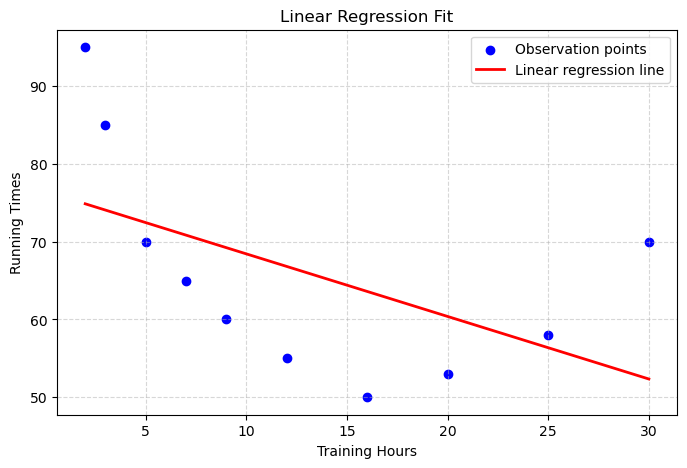

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Our data
training_hours = np.array([2, 3, 5, 7, 9, 12, 16, 20, 25, 30]).reshape(-1, 1)
running_times = np.array([95, 85, 70, 65, 60, 55, 50, 53, 58, 70])

model = LinearRegression()
model.fit(training_hours, running_times)
y_pred = model.predict(training_hours)
r2 = r2_score(running_times, y_pred)
mse = mean_squared_error(running_times, y_pred)

print(f"MSE: {mse:.7f}")
print(f"R²:  {r2:.7f}")

plt.figure(figsize=(8, 5))
plt.scatter(training_hours, running_times, color='blue', label='Observation points')
plt.plot(training_hours, y_pred, color='red', linewidth=2, label='Linear regression line')
plt.xlabel('Training Hours')
plt.ylabel('Running Times')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

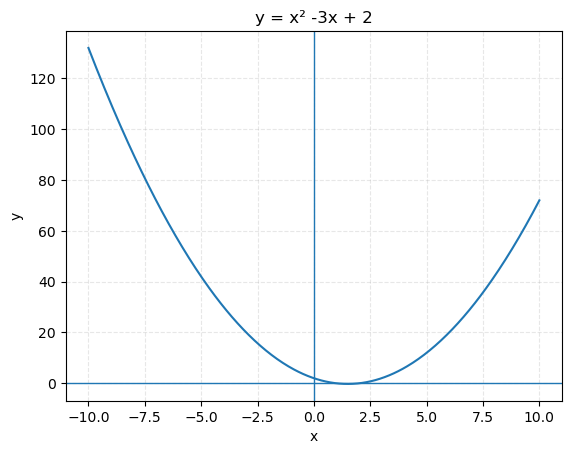

In [12]:
# 3) Plot a quadratic: y = ax² + bx + c
# A Quadratic is a specific type of mathematical equation 
# where the highest power (exponent) of the variable x is 2, meaning- x²
'''
Linear:    Highest power is 1 x  --> Makes a straight line
Quadratic: Highest power is 2 x²  --> Named after a 4-sided square
Cubic:     Highest power is 3 x^3 --> Named after a 3D cube
Quartic:   Highest power is 4 x^4 --> This is the one that actually uses 4 as its power!
'''
# Coefficients
a, b, c = 1.0, -3.0, 2.0  # y = x² - 3x + 2
x = np.linspace(-10, 10, 400)
y = a * x**2 + b * x + c

plt.figure()
plt.plot(x, y)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'y = x² -3x + 2')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()

coef [-4.24160825e-05  3.72439068e-03] : a, b
intercept 122.93175446710771 : c
Intercept (β₀) c: 122.93
Coefficient for x (β₁)  b: -17.71
Coefficient for x² (β₂) a: 2.02
y = 2.02x² + -17.71x + 122.93
r2= 0.9944561262449685
adjusted R2 score 0.9833683787349055


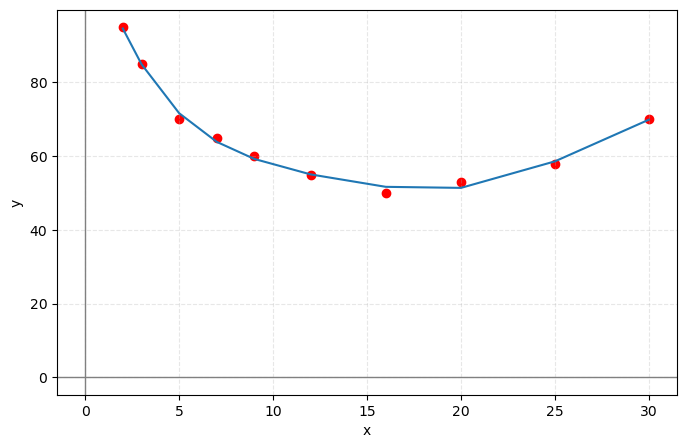

In [52]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Our data
training_hours = np.array([2, 3, 5, 7, 9, 12, 16, 20, 25, 30]).reshape(-1, 1)
running_times = np.array([95, 85, 70, 65, 60, 55, 50, 53, 58, 70])

# y = ax² + bx + 1*c
feature_engine = PolynomialFeatures(degree=5, include_bias=True)
X_poly = feature_engine.fit_transform(training_hours)

model = LinearRegression()
model.fit(X_poly, running_times)
print('coef', model.coef_[::-1][0:2], ': a, b')
print('intercept', model.intercept_, ': c')

intercept = model.intercept_
coefficients = model.coef_

print(f"Intercept (β₀) c: {intercept:.2f}")
print(f"Coefficient for x (β₁)  b: {coefficients[1]:.2f}")
print(f"Coefficient for x² (β₂) a: {coefficients[2]:.2f}")
a = coefficients[2]
b = coefficients[1]
c = intercept
print(f"y = {a:.2f}x² + {b:.2f}x + {c:.2f}")
r2 = r2_score(running_times, model.predict(X_poly))
print('r2=', r2)

from dmba import adjusted_r2_score
adj_r2 = adjusted_r2_score(running_times, model.predict(X_poly), model)

print('adjusted R2 score', adj_r2)

plt.figure(figsize=(8, 5))
plt.scatter(training_hours, running_times, color='red', label='Observation points')
plt.plot(training_hours, model.predict(X_poly))
plt.axhline(0, linewidth=1, color='gray')
plt.axvline(0, linewidth=1, color='gray')
plt.xlabel('x')
plt.ylabel('y')
# plt.title(f'y = x² -3x + 2')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()